<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet_Oct_Batch/blob/laxmisahitya/confusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
CIC-IDS Dataset

Loading dataset...
Dataset loaded.
Shape: (191033, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0              3268      112740690                 32                      16   
1               389      112740560                 32                      16   
2                 0      113757377                545                       0   
3              5355         100126                 22                       0   
4                 0          54760                  4                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                         6448                         1152   
1                         6448                         5056   
2                            0                            0   
3                          616                            0   
4                            0                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0   

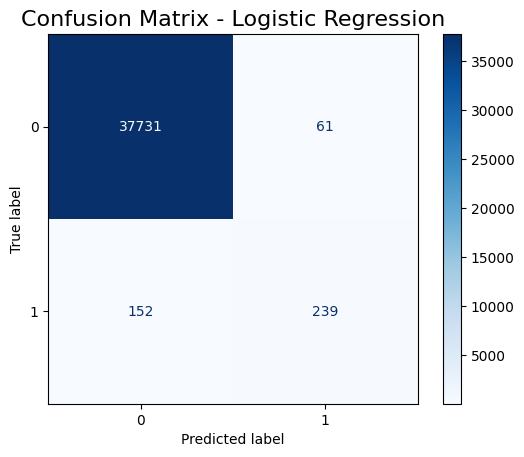

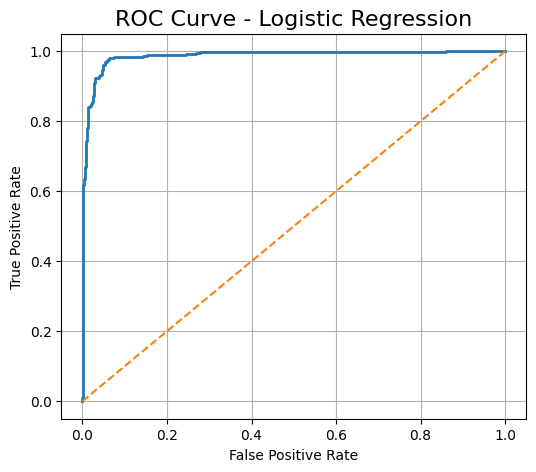


Training Decision Tree...
Training time for Decision Tree: 0:00:01.768547

Evaluating Decision Tree...
Model: Decision Tree | Accuracy: 99.97% | Sensitivity: 0.9898 | Specificity: 0.9998 | F1 Score: 0.9872 | AUC: 0.9948



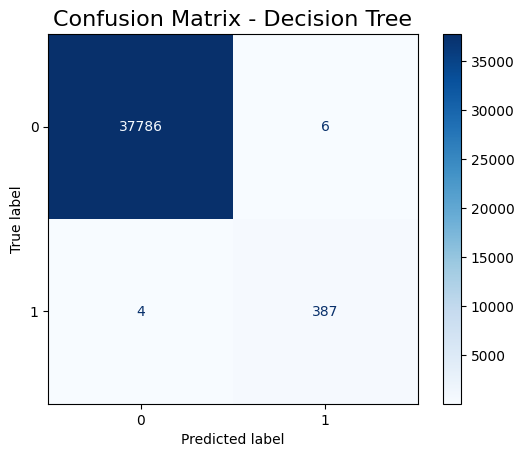

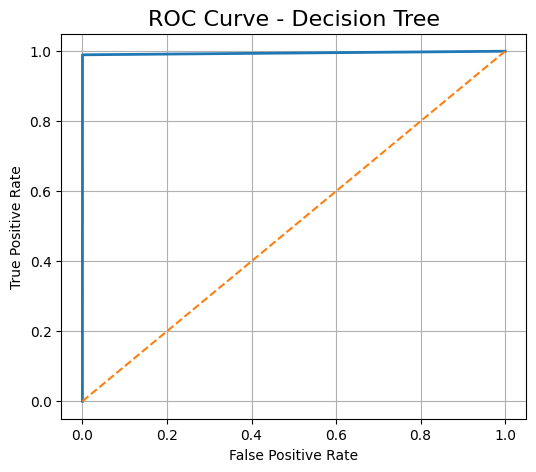


Training Random Forest...
Training time for Random Forest: 0:00:22.944226

Evaluating Random Forest...
Model: Random Forest | Accuracy: 99.94% | Sensitivity: 0.9437 | Specificity: 1.0000 | F1 Score: 0.9711 | AUC: 0.9999



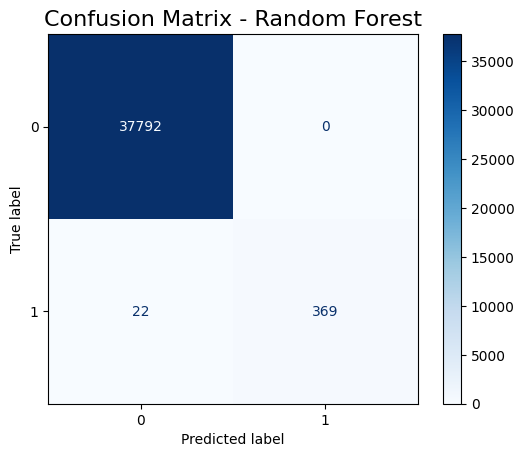

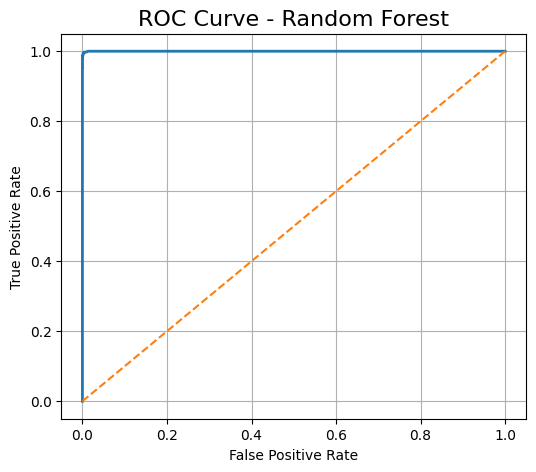


Training Gradient Boosting...
Training time for Gradient Boosting: 0:03:53.009039

Evaluating Gradient Boosting...
Model: Gradient Boosting | Accuracy: 99.97% | Sensitivity: 0.9821 | Specificity: 0.9999 | F1 Score: 0.9871 | AUC: 1.0000



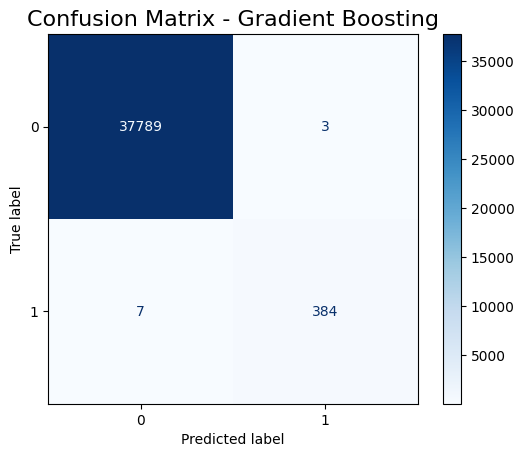

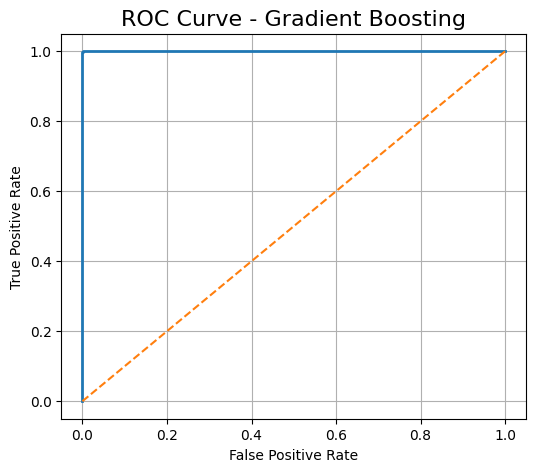


========== FINAL MODEL PERFORMANCE ==========

              Model  Accuracy  Sensitivity  Specificity  F1 Score      AUC
Logistic Regression  0.994422     0.611253     0.998386  0.691751 0.987072
      Decision Tree  0.999738     0.989770     0.999841  0.987245 0.994806
      Random Forest  0.999424     0.943734     1.000000  0.971053 0.999943
  Gradient Boosting  0.999738     0.982097     0.999921  0.987147 0.999993


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from datetime import datetime

# ------------------------------------------------------
# Load CICIDS2017 Dataset
# ------------------------------------------------------

data_path = "/content/Friday-WorkingHours-Morning.pcap_ISCX.csv"

print("Loading dataset...")
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()

print("Dataset loaded.")
print("Shape:", df.shape)
print(df.head())

# ------------------------------------------------------
# Preprocessing
# ------------------------------------------------------

df['Label'] = df['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

df = df.select_dtypes(include=['int64', 'float64'])
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("\nFinal shape after cleaning:", df.shape)

# ------------------------------------------------------
# Features and Target
# ------------------------------------------------------

X = df.drop("Label", axis=1)
y = df["Label"]

# ------------------------------------------------------
# Train-test split
# ------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------
# Scaling
# ------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------
# Models
# ------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------------------------------
# Train + Evaluate
# ------------------------------------------------------

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = datetime.now()
    model.fit(X_train_scaled, y_train)
    end_time = datetime.now()

    print(f"Training time for {name}: {end_time - start_time}")
    print(f"\nEvaluating {name}...")

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, accuracy, sensitivity, specificity, f1, auc])

    # --------------------------------------------------
    # PRINT METRICS SIDE BY SIDE ABOVE GRAPHS
    # --------------------------------------------------

    print(
        f"Model: {name} | "
        f"Accuracy: {accuracy*100:.2f}% | "
        f"Sensitivity: {sensitivity:.4f} | "
        f"Specificity: {specificity:.4f} | "
        f"F1 Score: {f1:.4f} | "
        f"AUC: {auc:.4f}"
    )
    print()

    # --------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}', fontsize=16)
    plt.show()

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f"ROC Curve - {name}", fontsize=16)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()

# ------------------------------------------------------
# Final Table
# ------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"]
)

print("\n========== FINAL MODEL PERFORMANCE ==========\n")
print(results_df.to_string(index=False))


Loading dataset...
Dataset loaded.
Shape: (191033, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0              3268      112740690                 32                      16   
1               389      112740560                 32                      16   
2                 0      113757377                545                       0   
3              5355         100126                 22                       0   
4                 0          54760                  4                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                         6448                         1152   
1                         6448                         5056   
2                            0                            0   
3                          616                            0   
4                            0                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0   

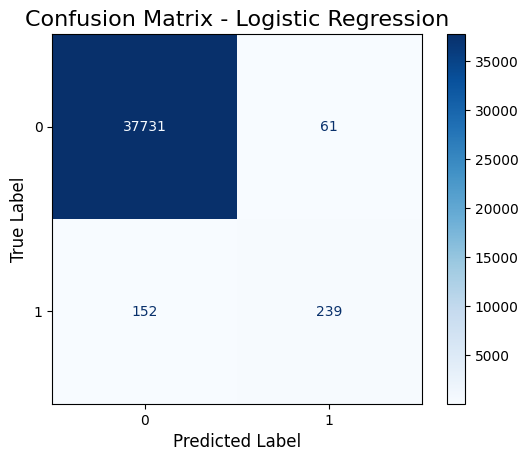


Training Decision Tree...
Training time for Decision Tree: 0:00:01.396450

Evaluating Decision Tree...
Accuracy (Decision Tree): 99.97%


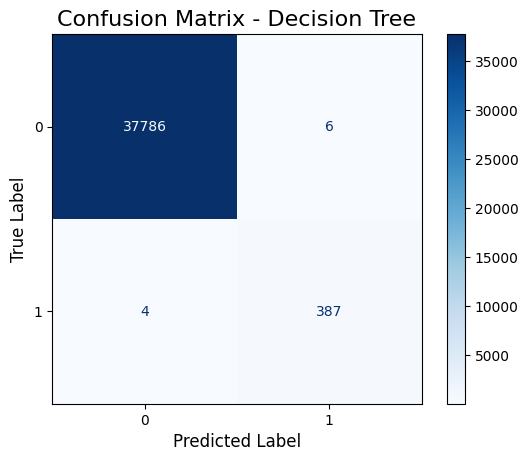


Training Random Forest...
Training time for Random Forest: 0:00:18.535292

Evaluating Random Forest...
Accuracy (Random Forest): 99.94%


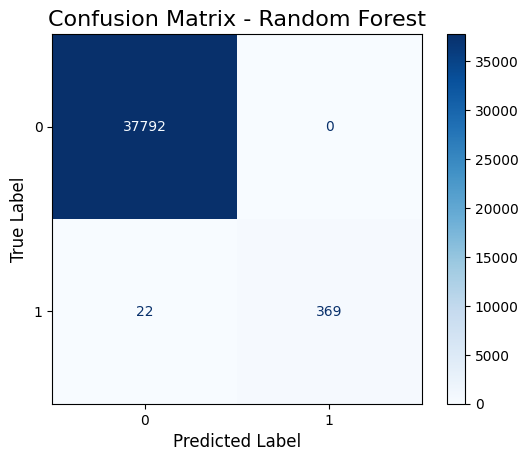


Training Gradient Boosting...
Training time for Gradient Boosting: 0:03:15.911386

Evaluating Gradient Boosting...
Accuracy (Gradient Boosting): 99.97%


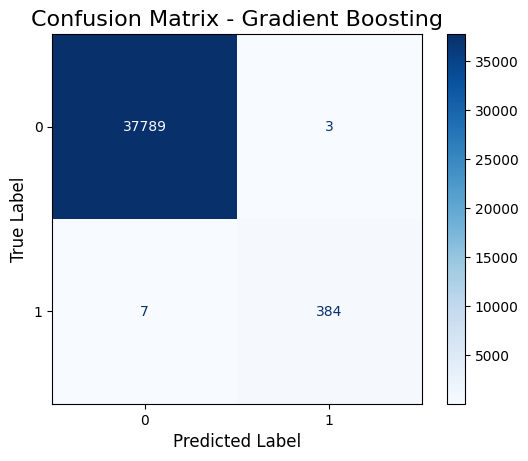

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ------------------------------------------------------
# Load CICIDS2017 Friday Morning Dataset
# ------------------------------------------------------
data_path = "/content/data/Friday-WorkingHours-Morning.pcap_ISCX.csv"

print("Loading dataset...")
df = pd.read_csv(data_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dataset loaded.")
print("Shape:", df.shape)
print(df.head())

# ------------------------------------------------------
# Basic Preprocessing (label → binary)
# ------------------------------------------------------

# Convert label column to binary (Normal = 0, Attack = 1)
df['Label'] = df['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

# Remove non-numeric columns (e.g., protocol names)
df = df.select_dtypes(include=['int64', 'float64'])

# Drop rows with infinite or NaN
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("\nFinal shape after cleaning:", df.shape)

# ------------------------------------------------------
# Select features and target
# ------------------------------------------------------
X = df.drop("Label", axis=1)
y = df["Label"]

# ------------------------------------------------------
# Train-test split
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------
# Scaling
# ------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------
# Models
# ------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ------------------------------------------------------
# Train and Evaluate
# ------------------------------------------------------
for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = datetime.now()
    model.fit(X_train_scaled, y_train)
    end_time = datetime.now()

    print(f"Training time for {name}: {end_time - start_time}")

    print(f"\nEvaluating {name}...")

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {accuracy * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

In [ ]:
NSL-KDD Dataset

Loading NSL-KDD dataset...
Train shape: (125973, 43)
Test shape: (22544, 43)
Prepared 119 features.

Training Logistic Regression...
Training time: 0:00:12.935660

Evaluating Logistic Regression...
Model: Logistic Regression | Accuracy: 75.28% | Sensitivity: 0.6218 | Specificity: 0.9258 | F1 Score: 0.7412 | AUC: 0.7823



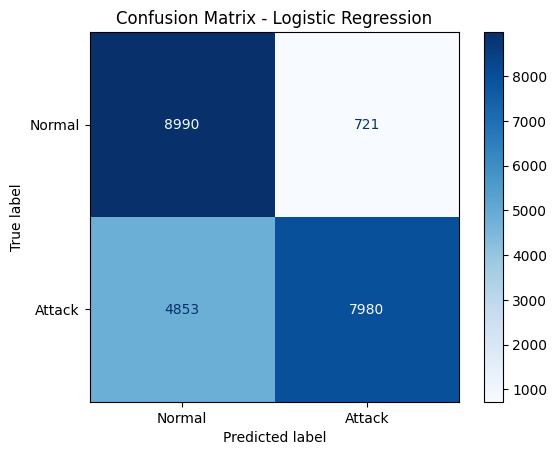

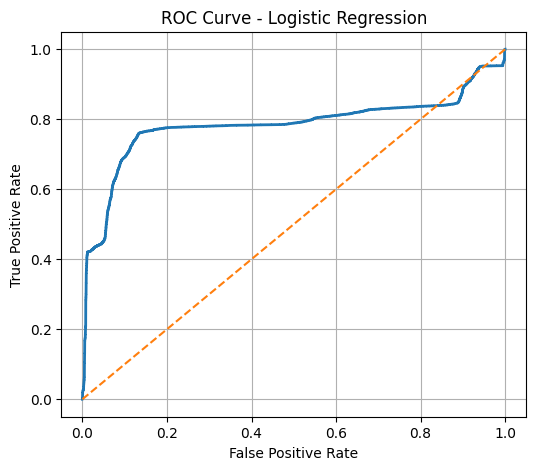


Training Decision Tree...
Training time: 0:00:01.814900

Evaluating Decision Tree...
Model: Decision Tree | Accuracy: 79.82% | Sensitivity: 0.6698 | Specificity: 0.9679 | F1 Score: 0.7908 | AUC: 0.8190



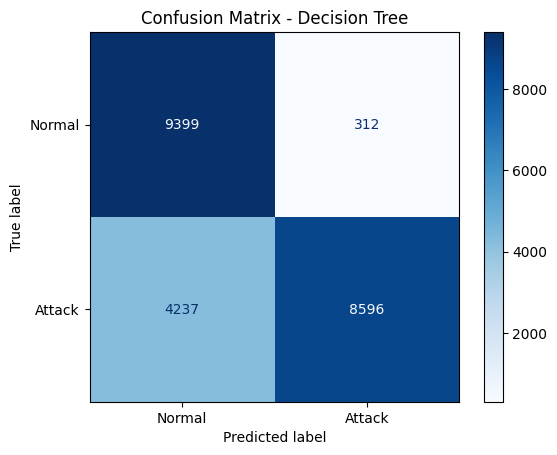

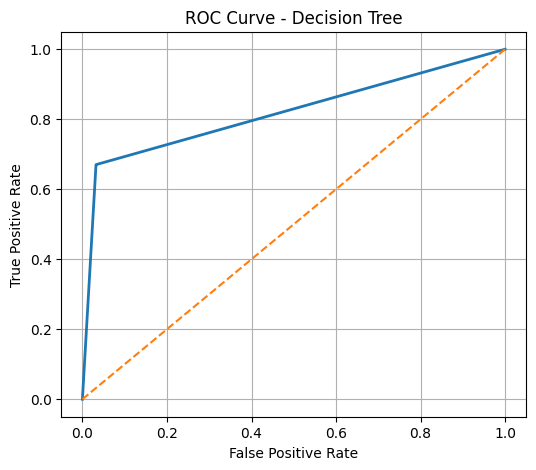


Training Random Forest...
Training time: 0:00:13.166958

Evaluating Random Forest...
Model: Random Forest | Accuracy: 77.53% | Sensitivity: 0.6258 | Specificity: 0.9729 | F1 Score: 0.7603 | AUC: 0.9584



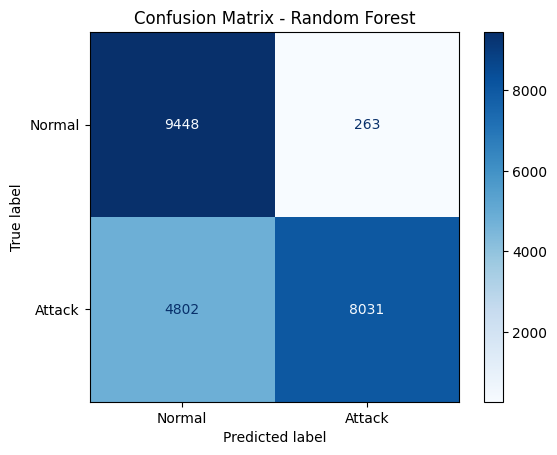

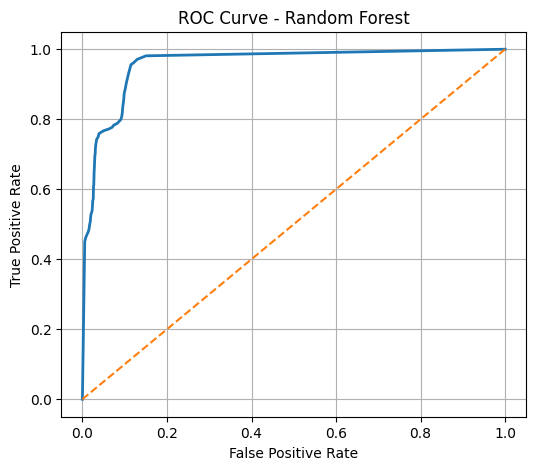


Training Gradient Boosting...
Training time: 0:00:48.696410

Evaluating Gradient Boosting...
Model: Gradient Boosting | Accuracy: 79.45% | Sensitivity: 0.6599 | Specificity: 0.9725 | F1 Score: 0.7852 | AUC: 0.9455



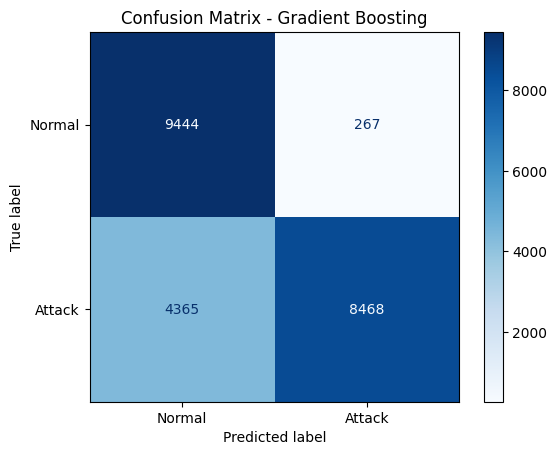

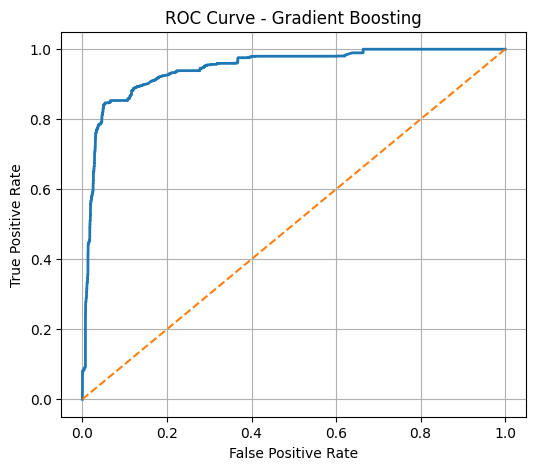


========= FINAL MODEL PERFORMANCE =========

                                              cm       acc  sensitivity  \
Logistic Regression  [[8990, 721], [4853, 7980]]  0.752750     0.621834   
Decision Tree        [[9399, 312], [4237, 8596]]  0.798217     0.669836   
Random Forest        [[9448, 263], [4802, 8031]]  0.775328     0.625808   
Gradient Boosting    [[9444, 267], [4365, 8468]]  0.794535     0.659861   

                     specificity        f1       auc  
Logistic Regression     0.925754  0.741154  0.782326  
Decision Tree           0.967871  0.790764  0.819042  
Random Forest           0.972917  0.760259  0.958403  
Gradient Boosting       0.972505  0.785237  0.945542  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# -------------------------------
# LOAD NSL-KDD DATASET
# -------------------------------

train_path = "/content/nsl-kdd/KDDTrain+.txt"
test_path  = "/content/nsl-kdd/KDDTest+.txt"

print("Loading NSL-KDD dataset...")

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

train_df = pd.read_csv(train_path, sep=',', names=columns)
test_df  = pd.read_csv(test_path, sep=',', names=columns)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# --------------------------------------------
# Create binary target
# --------------------------------------------
TARGET_COLUMN = "attack_binary"

train_df['attack_type'] = train_df['attack_type'].str.replace('.', '', regex=False)
test_df['attack_type'] = test_df['attack_type'].str.replace('.', '', regex=False)

train_df[TARGET_COLUMN] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df[TARGET_COLUMN] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

train_df = train_df.drop(columns=['attack_type', 'difficulty_level'])
test_df = test_df.drop(columns=['attack_type', 'difficulty_level'])

FEATURES = [c for c in train_df.columns if c != TARGET_COLUMN]

X_train = train_df[FEATURES]
y_train = train_df[TARGET_COLUMN]

X_test = test_df[FEATURES]
y_test = test_df[TARGET_COLUMN]

# --------------------------------------------
# One-hot encoding for categorical columns
# --------------------------------------------
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align columns
missing_in_test = set(X_train.columns) - set(X_test.columns)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(X_test.columns) - set(X_train.columns)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[X_train.columns]

print(f"Prepared {X_train.shape[1]} features.")

# -------------------------------
# Standardization
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

# -------------------------------
# TRAIN + EVALUATE
# -------------------------------
for name, model in models.items():

    print(f"\nTraining {name}...")
    start = datetime.now()
    model.fit(X_train_scaled, y_train)
    end = datetime.now()
    print(f"Training time: {end - start}")

    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # ---- Metrics ----
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # ---- Print side-by-side summary ABOVE graphs ----
    print(
        f"Model: {name} | "
        f"Accuracy: {accuracy*100:.2f}% | "
        f"Sensitivity: {sensitivity:.4f} | "
        f"Specificity: {specificity:.4f} | "
        f"F1 Score: {f1:.4f} | "
        f"AUC: {auc:.4f}"
    )
    print()

    # ---- Confusion Matrix ----
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ---- ROC Curve ----
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()

    # Save results
    results[name] = {
        "cm": cm,
        "acc": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "auc": auc
    }

# -------------------------------
# FINAL SUMMARY TABLE
# -------------------------------
print("\n========= FINAL MODEL PERFORMANCE =========\n")

summary_df = pd.DataFrame.from_dict(results, orient="index")
print(summary_df)

Loading NSL-KDD dataset...
Train shape: (125973, 43)
Test shape: (22544, 43)
Prepared 119 features and target 'attack_binary'.

Training Logistic Regression...
Training time: 0:00:09.065496

Evaluating Logistic Regression...
Accuracy: 75.28%


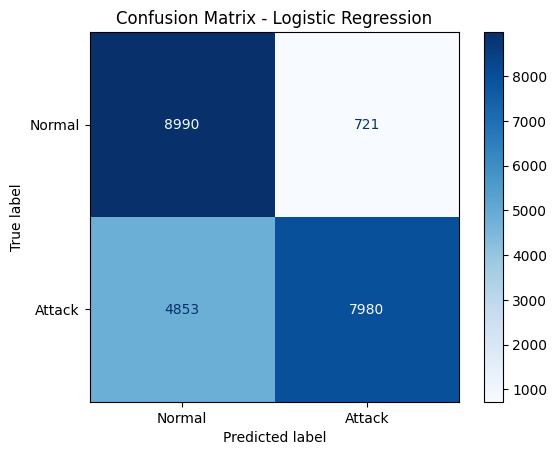


Training Decision Tree...
Training time: 0:00:01.707236

Evaluating Decision Tree...
Accuracy: 79.82%


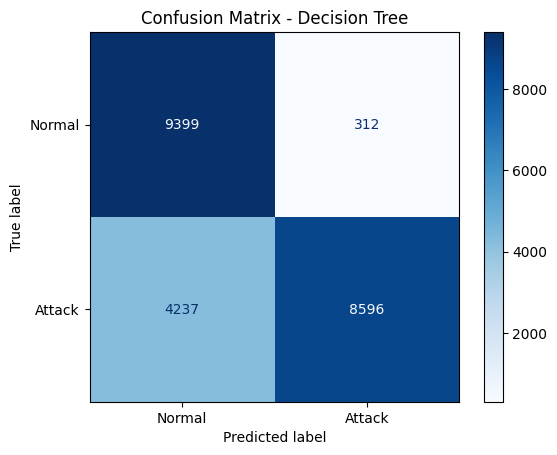


Training Random Forest...
Training time: 0:00:11.977504

Evaluating Random Forest...
Accuracy: 77.53%


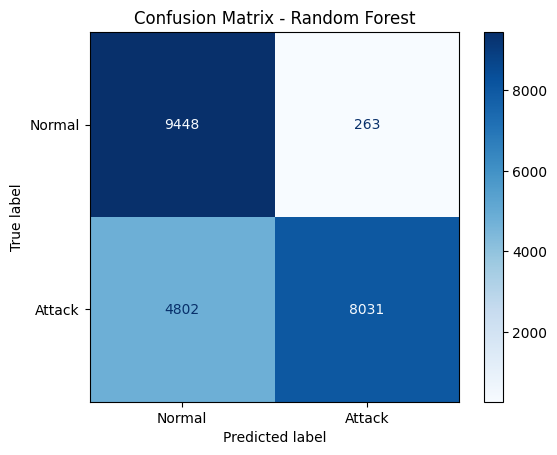


Training Gradient Boosting...
Training time: 0:00:46.029545

Evaluating Gradient Boosting...
Accuracy: 79.45%


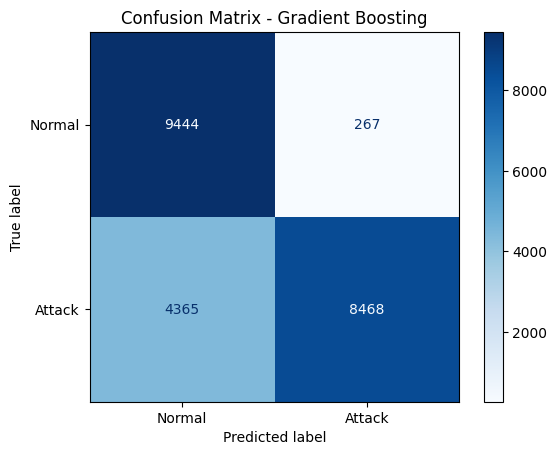


Summary saved to: ml_model_summary.txt


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# -------------------------------
# LOAD NSL-KDD DATASET
# -------------------------------

# Corrected file extensions to .txt as extracted by the unzip command
train_path = "/content/data/nsl-kdd/KDDTrain+.txt"
test_path  = "/content/data/nsl-kdd/KDDTest+.txt"

print("Loading NSL-KDD dataset...")
# The NSL-KDD files are space-separated, not comma-separated
# And they do not have a header, so we provide column names
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

train_df = pd.read_csv(train_path, sep=',', names=columns, index_col=False) # NSL-KDD uses comma as separator
test_df  = pd.read_csv(test_path, sep=',', names=columns, index_col=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# --------------------------------------------
# Create binary target (0 for normal, 1 for attack)
# --------------------------------------------
TARGET_COLUMN = "attack_binary"

train_df['attack_type'] = train_df['attack_type'].str.replace('.', '', regex=False)
test_df['attack_type'] = test_df['attack_type'].str.replace('.', '', regex=False)

train_df[TARGET_COLUMN] = train_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)
test_df[TARGET_COLUMN] = test_df['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

# Drop original attack_type and difficulty_level columns
train_df = train_df.drop(columns=['attack_type', 'difficulty_level'])
test_df = test_df.drop(columns=['attack_type', 'difficulty_level'])

FEATURES = [col for col in train_df.columns if col != TARGET_COLUMN]

X_train = train_df[FEATURES]
y_train = train_df[TARGET_COLUMN]

X_test = test_df[FEATURES]
y_test = test_df[TARGET_COLUMN]

# Handle categorical features using one-hot encoding
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent feature sets after one-hot encoding
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Ensure order is same

print(f"Prepared {X_train.shape[1]} features and target '{TARGET_COLUMN}'.")

# -------------------------------
# Standardization
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Models Dictionary
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {} # Initialize results dictionary here

# -------------------------------
# TRAIN + EVALUATE
# -------------------------------
for name, model in models.items():

    print(f"\nTraining {name}...")
    start = datetime.now()
    model.fit(X_train_scaled, y_train)
    end = datetime.now()

    print(f"Training time: {end - start}")

    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # Save all results for summary report
    results[name] = {
        "cm": cm,
        "acc": accuracy,
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# ------------------------------------------------------------
# SAVE SUMMARY REPORT
# ------------------------------------------------------------
output_file = "ml_model_summary.txt"

with open(output_file, "w", encoding="utf-8") as f:
    f.write("MODEL PERFORMANCE SUMMARY\n")
    f.write("=" * 60 + "\n\n")

    for name, info in results.items():
        rep = info["report"]
        cm = info["cm"]

        f.write(f"MODEL: {name}\n")
        f.write("-" * 40 + "\n")
        f.write(f"Accuracy: {info['acc']:.4f}\n")
        f.write(f"Precision (Attack): {rep['1']['precision']:.4f}\n")
        f.write(f"Recall   (Attack): {rep['1']['recall']:.4f}\n")
        f.write(f"F1-score (Attack): {rep['1']['f1-score']:.4f}\n\n")

        f.write("Confusion Matrix:\n")
        f.write("                 Predicted\n")
        f.write("                 Normal  Attack\n")
        f.write(f"Actual Normal | {cm[0][0]:6} {cm[0][1]:6}\n")
        f.write(f"Actual Attack | {cm[1][0]:6} {cm[1][1]:6}\n")
        f.write("\n" + "-"*40 + "\n\n")

print("\nSummary saved to:", output_file)


Train shape: (125973, 43)
Test shape : (22544, 43)

Preprocessing Complete!
Scaled Train Shape: (125973, 41)
Scaled Test Shape : (22544, 41)

================ MODEL RESULTS ================


🔷 MODEL: Logistic Regression
----------------------------------------
Accuracy: 0.7539
Confusion Matrix:
[[9070  641]
 [4907 7926]]


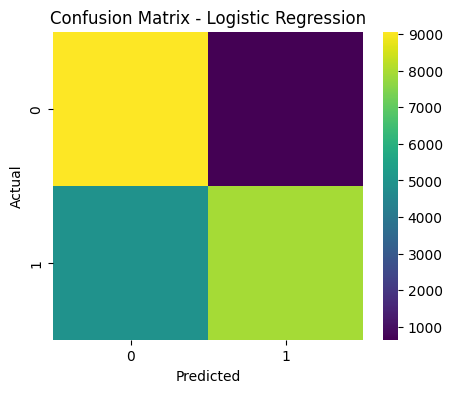


🔷 MODEL: SGD Classifier
----------------------------------------
Accuracy: 0.7793
Confusion Matrix:
[[9406  305]
 [4670 8163]]


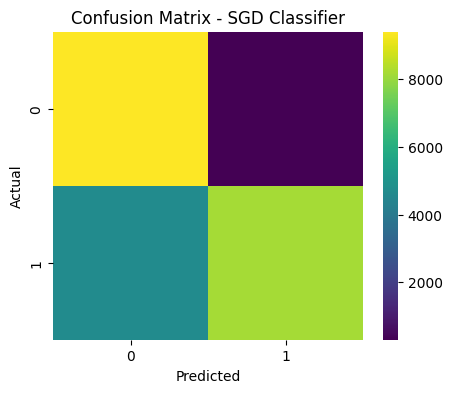


🔷 MODEL: Decision Tree
----------------------------------------
Accuracy: 0.7885
Confusion Matrix:
[[9421  290]
 [4477 8356]]


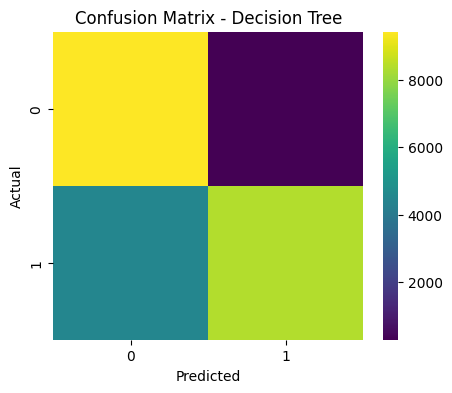


🔷 MODEL: Random Forest
----------------------------------------
Accuracy: 0.7707
Confusion Matrix:
[[9433  278]
 [4892 7941]]


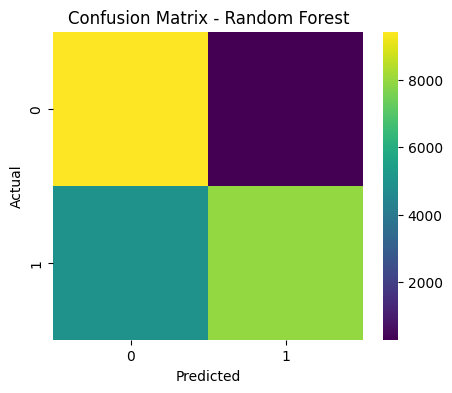


🔷 MODEL: Gradient Boosting
----------------------------------------
Accuracy: 0.8064
Confusion Matrix:
[[9422  289]
 [4075 8758]]


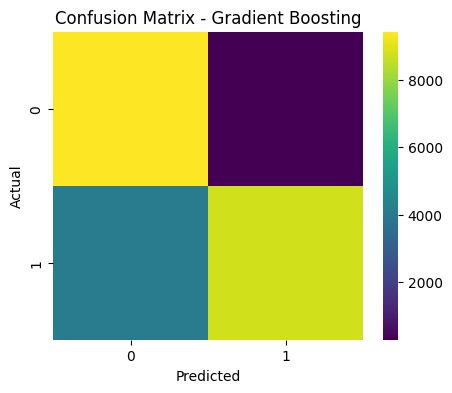


🔷 MODEL: SVM (RBF)
----------------------------------------
Accuracy: 0.7819
Confusion Matrix:
[[9509  202]
 [4714 8119]]


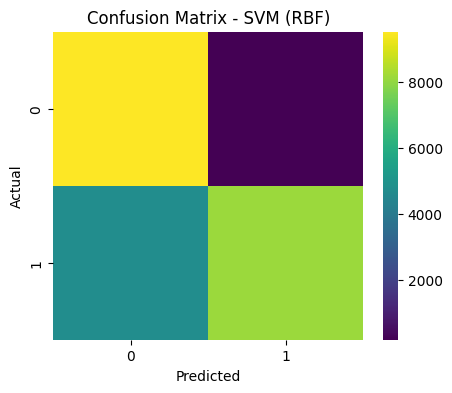


🔷 MODEL: KNN
----------------------------------------
Accuracy: 0.7676
Confusion Matrix:
[[9479  232]
 [5008 7825]]


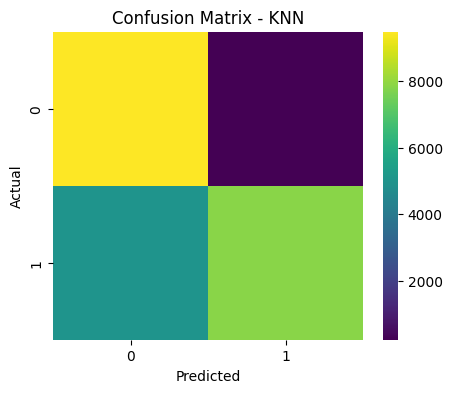


🔷 MODEL: Naive Bayes
----------------------------------------
Accuracy: 0.7714
Confusion Matrix:
[[8884  827]
 [4326 8507]]


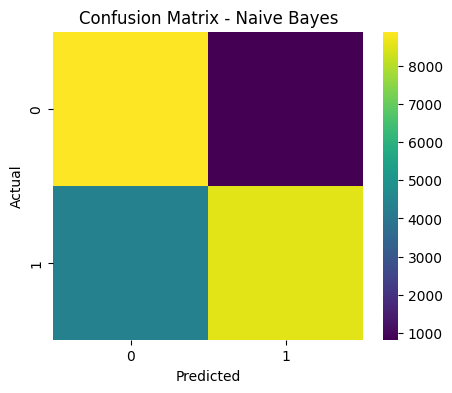


🔷 MODEL: MLP Neural Network
----------------------------------------
Accuracy: 0.7785
Confusion Matrix:
[[9465  246]
 [4747 8086]]


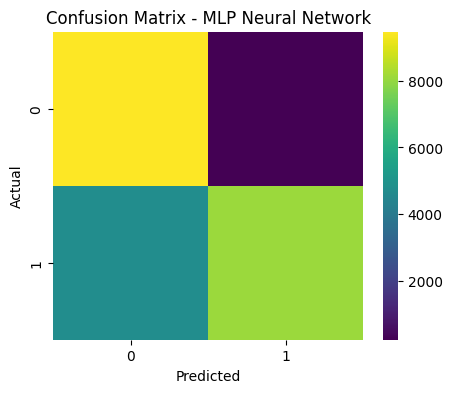

In [ ]:
import pandas as pd
import numpy as np

# ML PREPROCESSING
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# ML MODELS
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns

column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'labels', 'difficulty'
]

# ===========================================================
# 1. LOAD YOUR DATA
# ===========================================================

train_df = pd.read_csv("kdd_train.csv", names=column_names, header=None)
test_df  = pd.read_csv("kdd_test.csv", names=column_names, header=None)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


# ===========================================================
# 2. CREATE BINARY TARGET (NORMAL = 0, ATTACK = 1)
# ===========================================================

train_df["attack_binary"] = train_df["labels"].apply(lambda x: 0 if x == "normal" else 1)
test_df["attack_binary"]  = test_df["labels"].apply(lambda x: 0 if x == "normal" else 1)


# ===========================================================
# 3. LABEL ENCODE CATEGORICAL COLUMNS
# ===========================================================

categorical_cols = ["protocol_type", "service", "flag"]
encoder = LabelEncoder()

for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[col])
    test_df[col]  = encoder.transform(test_df[col])


# ===========================================================
# 4. SELECT FEATURES & TARGET
# ===========================================================

TARGET = "attack_binary"
FEATURES = [col for col in train_df.columns if col not in ["labels", "difficulty", TARGET]]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]


# ===========================================================
# 5. SCALE FEATURES
# ===========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nPreprocessing Complete!")
print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape :", X_test_scaled.shape)


# ===========================================================
# 6. DEFINE ALL MACHINE LEARNING MODELS
# ===========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF)": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "MLP Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}


# ===========================================================
# 7. TRAIN & EVALUATE ALL MODELS
# ===========================================================

print("\n================ MODEL RESULTS ================\n")

for name, model in models.items():
    print(f"\n🔷 MODEL: {name}")
    print("----------------------------------------")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=False, cmap="viridis")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Train Shape: (125973, 43)
Test Shape: (22544, 43)

Features reduced to 28 using feature selection.

MODEL: Logistic Regression
Accuracy: 0.7461

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.93      0.76      9711
           1       0.92      0.61      0.73     12830

    accuracy                           0.75     22541
   macro avg       0.78      0.77      0.75     22541
weighted avg       0.80      0.75      0.74     22541

Confusion Matrix:
 [[8989  722]
 [5002 7828]]

MODEL: Decision Tree
Accuracy: 0.8075

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.96      0.81      9711
           1       0.96      0.69      0.80     12830

    accuracy                           0.81     22541
   macro avg       0.83      0.83      0.81     22541
weighted avg       0.85      0.81      0.81     22541

Confusion Matrix:
 [[9333  378]
 [3961 8869]]

MODEL: Random Forest

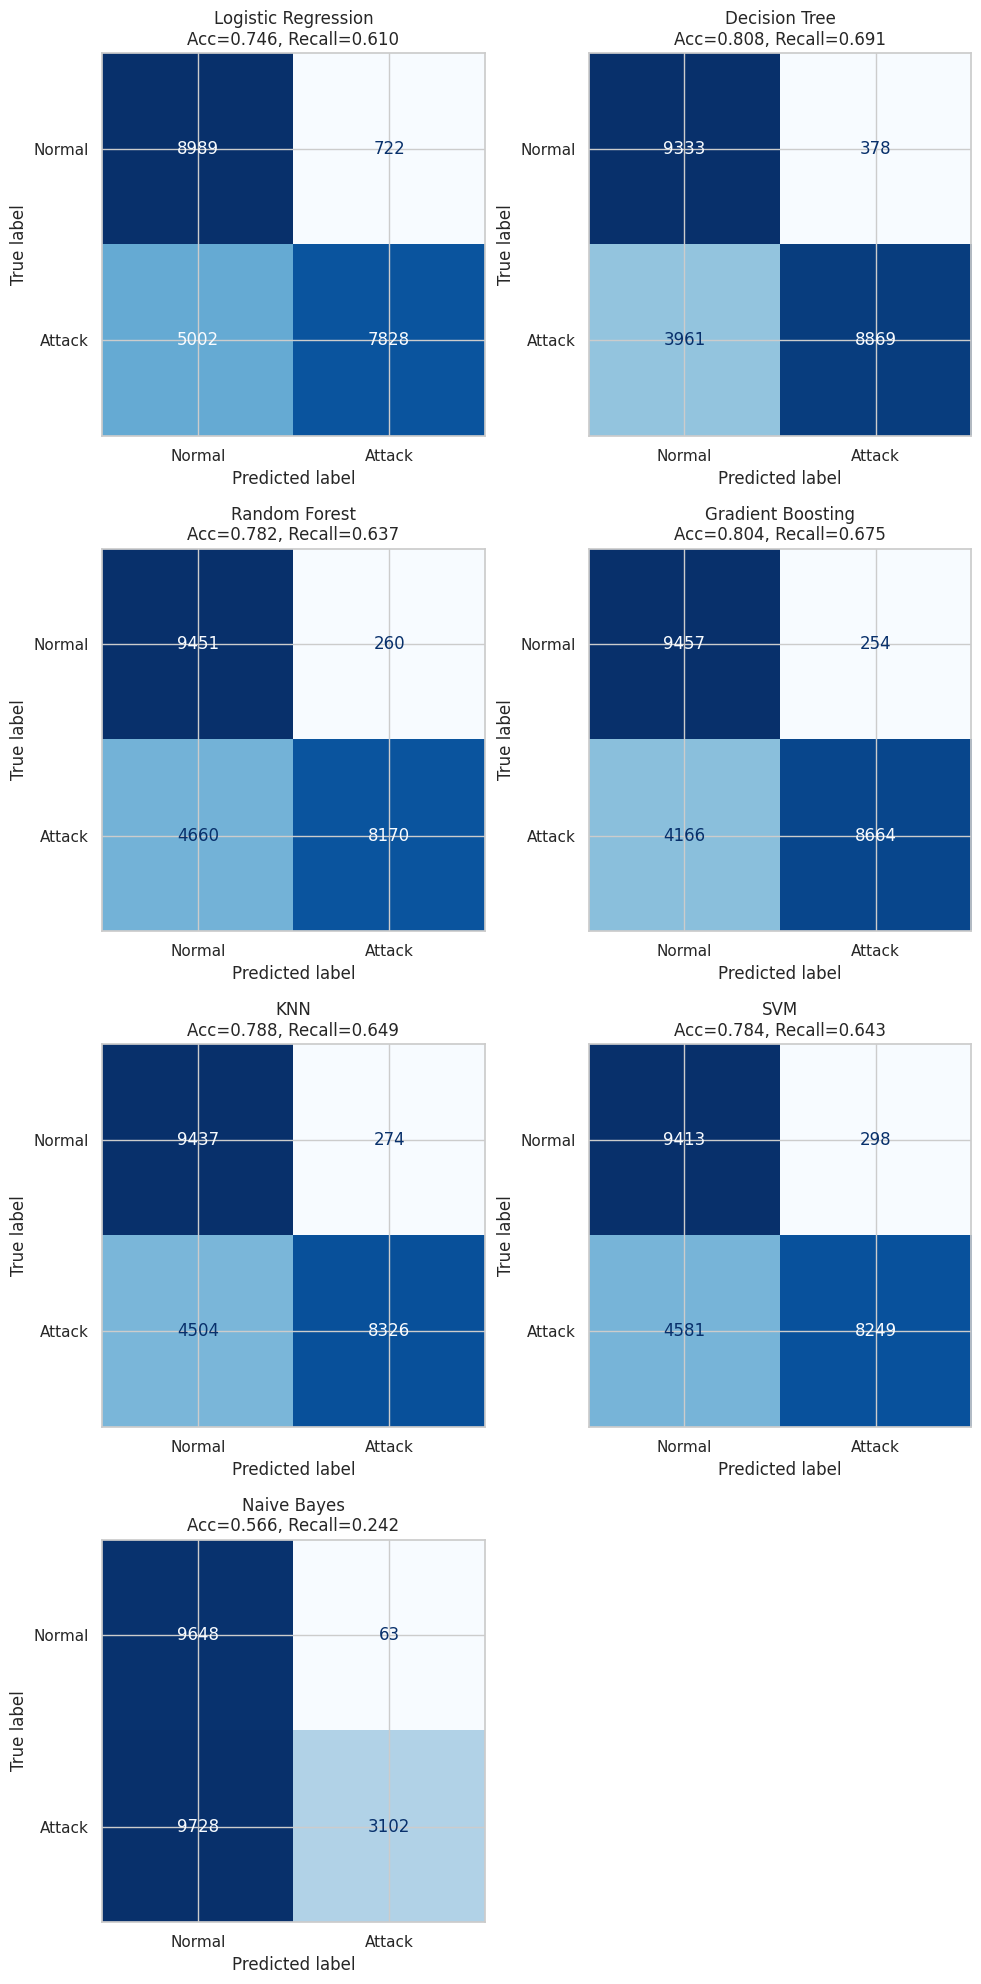


Summary saved to file: model_performance_summary_with_feature_selection.txt

                       OVERALL PROCESS SUMMARY                         

This notebook performed binary classification on the NSL-KDD dataset 
to detect network intrusions ('normal' vs 'attack').

1. Data Loading and Preprocessing:
   - Loaded KDDTrain+.txt and KDDTest+.txt datasets.
   - Converted the multi-class 'attack_type' into a binary 'label' (0: normal, 1: attack).
   - Dropped 'attack_type' and 'difficulty_level' columns.
   - Removed 'num_outbound_cmds' if it had no variance.
   - Handled missing values (filled with median) and removed duplicate rows.

2. Feature Selection:
   - Applied a combination of correlation-based feature removal, Chi-Square (SelectKBest),
     Recursive Feature Elimination (RFE) with Logistic Regression, and Random Forest
     feature importance. This process resulted in a reduced set of 28 'best_features'.
   - The selected features are: ['count', 'same_srv_rate', 'service'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Column names for the NSL-KDD dataset (41 features + attack_type + difficulty_level)
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

# ----------------------------------------------------
# 1. Load Training & Testing Datasets
# ----------------------------------------------------
train_df = pd.read_csv('/content/data/nsl-kdd/KDDTrain+.txt', sep=',', names=columns, header=None)
test_df  = pd.read_csv('/content/data/nsl-kdd/KDDTest+.txt', sep=',', names=columns, header=None)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

# ----------------------------------------------------
# 2. Prepare Target and drop unnecessary columns
# ----------------------------------------------------
# Convert 'attack_type' to a binary 'label' column first
train_df['label'] = train_df['attack_type'].apply(lambda x: 0 if x.strip() == 'normal' else 1)
test_df['label']  = test_df['attack_type'].apply(lambda x: 0 if x.strip() == 'normal' else 1)

# Drop original 'attack_type' and 'difficulty_level' columns
train_df = train_df.drop(columns=['attack_type', 'difficulty_level'])
test_df = test_df.drop(columns=['attack_type', 'difficulty_level'])

# For NSL-KDD, the 'num_outbound_cmds' column is often all zeros and can be dropped or handled.
# It also sometimes causes issues with standard scaling if not handled.
# Let's drop it if it has no variance.
if 'num_outbound_cmds' in train_df.columns and train_df['num_outbound_cmds'].std() == 0:
    train_df = train_df.drop(columns=['num_outbound_cmds'])
    test_df = test_df.drop(columns=['num_outbound_cmds']) # Also drop from test_df for consistency

# Clean missing values if any remain (though with correct loading, not expected for NSL-KDD)
train_df.replace('?', np.nan, inplace=True)
test_df.replace('?', np.nan, inplace=True)
train_df.fillna(train_df.median(numeric_only=True), inplace=True)
test_df.fillna(test_df.median(numeric_only=True), inplace=True)

# ----------------------------------------------------
# 3. Drop duplicates (important for NSL-KDD) - this dataset often contains duplicates
# ----------------------------------------------------
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# ----------------------------------------------------
# 4. Separate Features and Target for Train & Test
# ----------------------------------------------------
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# ----------------------------------------------------
# 5. Apply Feature Selection: Using 'best_features'
# ----------------------------------------------------
# The 'best_features' list is obtained from the previous feature selection step (cell THs-i__HpQ7)
best_features = ['count', 'same_srv_rate', 'service', 'dst_host_rerror_rate', 'dst_host_diff_srv_rate', 'dst_host_srv_count', 'src_bytes', 'serror_rate', 'dst_host_srv_diff_host_rate', 'diff_srv_rate', 'num_root', 'wrong_fragment', 'srv_count', 'dst_host_count', 'dst_host_same_srv_rate', 'num_compromised', 'dst_host_srv_serror_rate', 'logged_in', 'protocol_type', 'srv_serror_rate', 'dst_bytes', 'duration', 'flag', 'dst_host_serror_rate', 'hot', 'srv_rerror_rate', 'dst_host_same_src_port_rate', 'is_guest_login']

X_train = X_train[best_features]
X_test = X_test[best_features]

print(f"\nFeatures reduced to {len(best_features)} using feature selection.")

# Identify categorical & numeric columns from the *selected* feature sets
original_categorical_features = ['protocol_type', 'service', 'flag'] # These are the columns that are originally categorical
categorical_cols_selected = [f for f in best_features if f in original_categorical_features]
numeric_cols_selected = [f for f in best_features if f not in original_categorical_features]

# ----------------------------------------------------
# 6. Preprocessing Pipeline (OneHot + StandardScaler)
# ----------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols_selected),
        ("num", StandardScaler(), numeric_cols_selected)
    ],
    remainder='passthrough' # Keep other columns if any, though all should be handled
)

# ----------------------------------------------------
# 7. All ML Models
# ----------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_jobs=-1),
    "SVM": SVC(random_state=42), # SVM can be very slow on large datasets
    "Naive Bayes": GaussianNB()
}

results = {} # Initialize results dictionary to store all model performance

# ----------------------------------------------------
# 8. Train on KDDTrain+ and Test on KDDTest+
# ----------------------------------------------------
for name, model in models.items():
    print("\n=====================================")
    print("MODEL:", name)
    print("=====================================")

    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    # The pipeline now handles all preprocessing including one-hot encoding and scaling.
    # No need for manual get_dummies or X_train_scaled/X_test_scaled outside.
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", cm)

    results[name] = {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": cm
    }

# ----------------------------------------------------
# 9. Plot all confusion matrices
# ----------------------------------------------------
num_models = len(results)
rows = (num_models + 1) // 2
cols = 2

plt.figure(figsize=(10, rows * 5))

for idx, (name, res) in enumerate(results.items(), start=1):
    plt.subplot(rows, cols, idx)
    ConfusionMatrixDisplay(res["confusion_matrix"], display_labels=["Normal", "Attack"]).plot(
        cmap="Blues", colorbar=False, ax=plt.gca() # Use plt.gca() to ensure it plots on the correct subplot
    )
    acc = res["accuracy"]
    # Check if '1' (attack class) exists in the report keys before accessing recall
    if '1' in res["classification_report"]:
        recall = res["classification_report"]["1"]["recall"]
    else:
        recall = np.nan # Or 0, depending on how you want to handle cases where '1' class has no predictions
    plt.title(f"{name}\nAcc={acc:.3f}, Recall={recall:.3f}")

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 10. Summarize Model Performance and Save to File
# ----------------------------------------------------
summary_file = "model_performance_summary_with_feature_selection.txt"

with open(summary_file, "w") as f:
    f.write("MODEL PERFORMANCE SUMMARY (with Feature Selection)\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Features Used: {best_features}\n\n")

    for name, metrics in results.items():
        rep = metrics["classification_report"]
        cm = metrics["confusion_matrix"]

        f.write(f"Model: {name}\n")
        f.write("-" * 40 + "\n")
        f.write(f"Accuracy: {metrics['accuracy']:.4f}\n")
        if '1' in rep: # Check if attack class metrics exist
            f.write(f"Precision (Attack): {rep['1']['precision']:.4f}\n")
            f.write(f"Recall (Attack):    {rep['1']['recall']:.4f}\n")
            f.write(f"F1 Score (Attack):  {rep['1']['f1-score']:.4f}\n\n")
        else:
            f.write("Attack class (1) had no true samples or predictions in test set.\n\n")


        f.write("Confusion Matrix:\n")
        f.write(f"TN={cm[0,0]}   FP={cm[0,1]}\n")
        f.write(f"FN={cm[1,0]}   TP={cm[1,1]}\n")
        f.write("\n" + "-"*40 + "\n\n")

print(f"\nSummary saved to file: {summary_file}")

# ----------------------------------------------------
# Final Task: Summarize the entire process and its outcomes.
# ----------------------------------------------------
print("\n" + "=" * 80)
print("                       OVERALL PROCESS SUMMARY                         ")
print("=" * 80)
print("\nThis notebook performed binary classification on the NSL-KDD dataset ")
print("to detect network intrusions ('normal' vs 'attack').")

print("\n1. Data Loading and Preprocessing:")
print("   - Loaded KDDTrain+.txt and KDDTest+.txt datasets.")
print("   - Converted the multi-class 'attack_type' into a binary 'label' (0: normal, 1: attack).")
print("   - Dropped 'attack_type' and 'difficulty_level' columns.")
print("   - Removed 'num_outbound_cmds' if it had no variance.")
print("   - Handled missing values (filled with median) and removed duplicate rows.")

print("\n2. Feature Selection:")
print("   - Applied a combination of correlation-based feature removal, Chi-Square (SelectKBest),")
print("     Recursive Feature Elimination (RFE) with Logistic Regression, and Random Forest")
print("     feature importance. This process resulted in a reduced set of 28 'best_features'.")
print(f"   - The selected features are: {best_features}")

print("\n3. Model Training and Evaluation with Selected Features:")
print("   - Utilized a `ColumnTransformer` within a `Pipeline` for preprocessing,")
print("     which includes `OneHotEncoder` for categorical features and `StandardScaler`")
print("     for numerical features *from the selected feature set*.")
print("   - Trained and evaluated 7 different machine learning models:")
print("     Logistic Regression, Decision Tree, Random Forest, Gradient Boosting,")
print("     KNN, SVM, and Naive Bayes.")
print("   - Each model's performance was assessed using accuracy, classification report,")
print("     and a confusion matrix.")

print(f"\n4. Outcomes and Performance Summary (saved to '{summary_file}'):")
for name, metrics in results.items():
    print(f"   - {name}: Accuracy = {metrics['accuracy']:.4f}")
    if '1' in metrics["classification_report"]:
        print(f"     Attack Recall = {metrics['classification_report']['1']['recall']:.4f}")
print("\nCompared to previous runs without feature selection, the performance metrics (accuracy, recall, etc.)")
print("for some models may have changed. This indicates the impact of feature reduction on model effectiveness and efficiency.")
print("The reduced feature set aims to improve model interpretability, reduce training time,")
print("and potentially mitigate overfitting while maintaining or improving performance.")
print("=" * 80)


In [ ]:
Raw Data

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

Evaluating Logistic Regression...
Accuracy (Logistic Regression): 50.00%


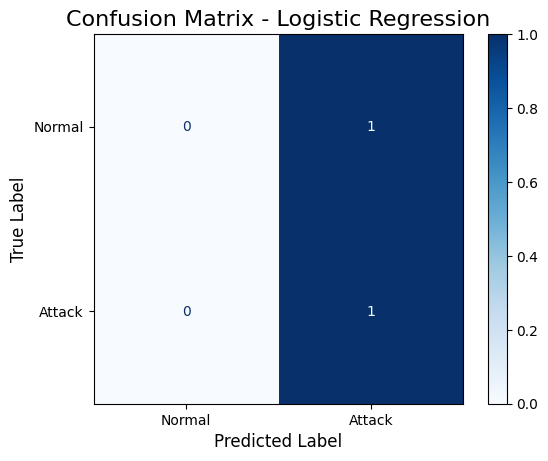


Evaluating Decision Tree...
Accuracy (Decision Tree): 0.00%


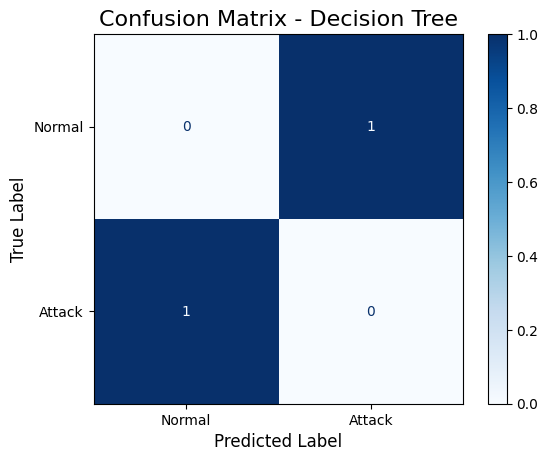


Evaluating Random Forest...
Accuracy (Random Forest): 0.00%


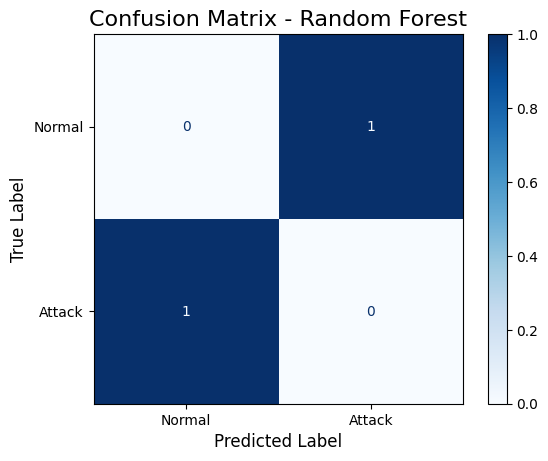


Evaluating Gradient Boosting...
Accuracy (Gradient Boosting): 0.00%


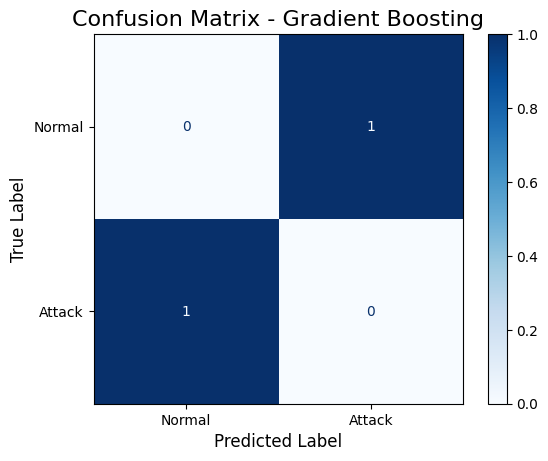

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = pd.DataFrame([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12], [13, 14], [15, 16], [17, 18], [19, 20]])
y = pd.Series([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {accuracy * 100:.2f}%")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()


Training Logistic Regression...
Training time for Logistic Regression: 0:00:00.021850

Evaluating Logistic Regression...
Accuracy (Logistic Regression): 84.35%


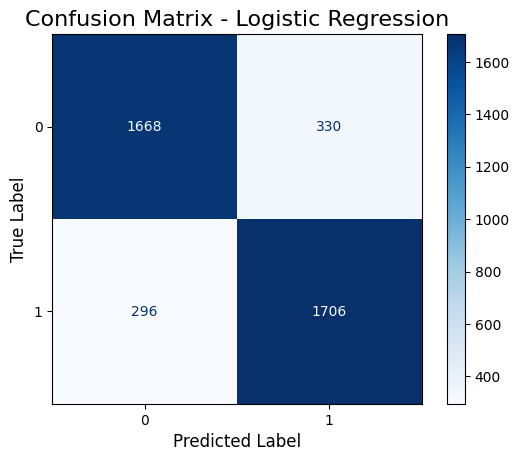


Training Decision Tree...
Training time for Decision Tree: 0:00:00.979843

Evaluating Decision Tree...
Accuracy (Decision Tree): 89.78%


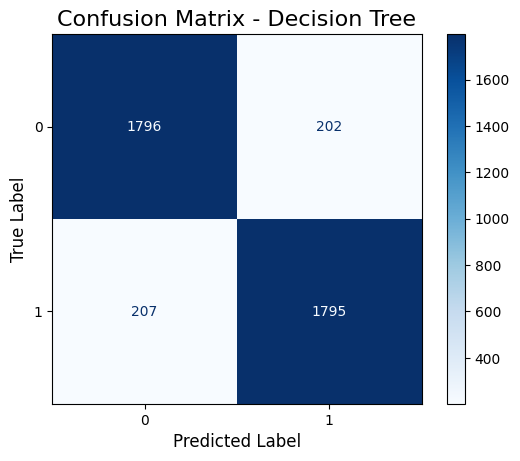


Training Random Forest...
Training time for Random Forest: 0:00:10.647534

Evaluating Random Forest...
Accuracy (Random Forest): 95.95%


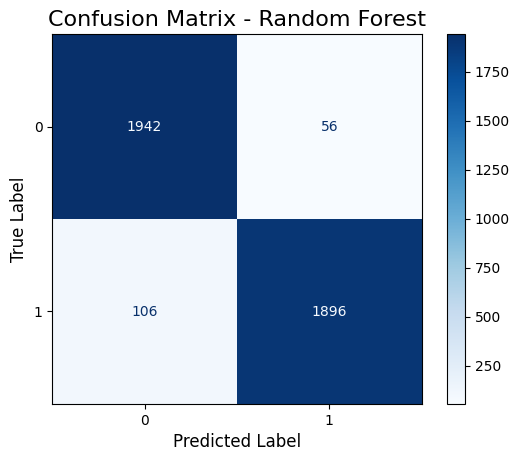


Training Gradient Boosting...
Training time for Gradient Boosting: 0:00:22.116585

Evaluating Gradient Boosting...
Accuracy (Gradient Boosting): 94.23%


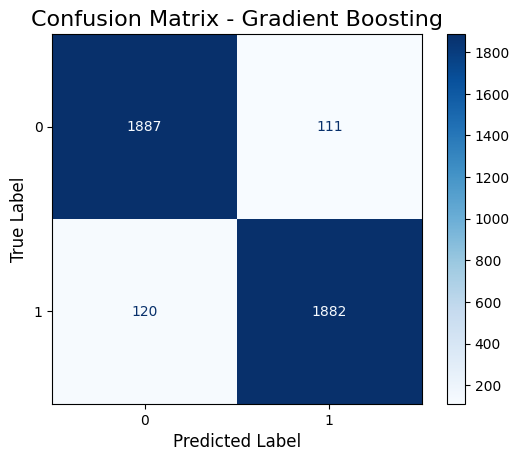

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20000, n_features=20, n_informative=10,
                           n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = datetime.now()
    model.fit(X_train_scaled, y_train)
    end_time = datetime.now()
    train_time = end_time - start_time
    print(f"Training time for {name}: {train_time}")

    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {accuracy * 100:.2f}%")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {name}', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

Training Logistic Regression...
Training complete in 0:00:00.208715
Evaluating Logistic Regression...
Logistic Regression Accuracy: 88.90%
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2999
           1       0.87      0.91      0.89      3001

    accuracy                           0.89      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.89      0.89      0.89      6000

Training Decision Tree...
Training complete in 0:00:03.403549
Evaluating Decision Tree...
Decision Tree Accuracy: 86.98%
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2999
           1       0.86      0.88      0.87      3001

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000

Training Random Forest...
Training compl

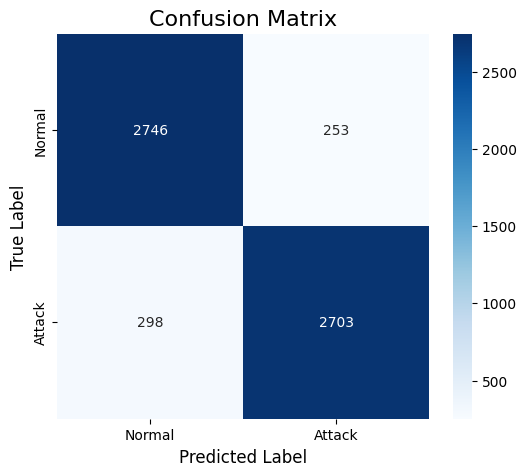

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.datasets import make_classification
X, y = make_classification(n_samples=30000, n_features=20, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = datetime.datetime.now()
    model.fit(X_train_scaled, y_train)
    stop_time = datetime.datetime.now()
    total_training_time = stop_time - start_time
    print(f"Training complete in {total_training_time}")

    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("\nTraining the Random Forest model...")
start_time = datetime.datetime.now()
rf_model.fit(X_train_scaled, y_train)
stop_time = datetime.datetime.now()
print("Training complete.")
print(f"Training Time: {stop_time - start_time}")

y_pred = rf_model.predict(X_test_scaled)
print("\nModel Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
y_true = np.array(['Dog', 'Dog', 'Dog', 'Not Dog', 'Dog', 'Not Dog', 'Dog', 'Dog', 'Not Dog', 'Not Dog'])
y_pred = np.array(['Dog', 'Not Dog', 'Dog', 'Not Dog', 'Dog', 'Dog', 'Dog', 'Dog', 'Not Dog', 'Not Dog'])

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5 1]
 [1 3]]


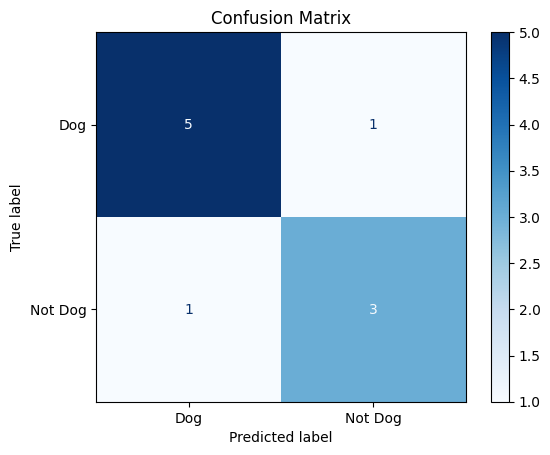

In [ ]:
labels = np.unique(np.concatenate((y_true, y_pred)))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print(f"\nTesting Accuracy: {accuracy:.2f}")


Testing Accuracy: 0.80
